<h1><strong>ANN</strong></h1>

ANN is a computational model inspired by the structure and functions of biological neural networks (the human brain). Think of it as a complex mathematical function that learns pattern from data to make predictions.

In [3]:
import numpy as np

def simple_neuron(inputs,weights,bias):
    weighted_sum= np.dot(inputs,weights) + bias

    output = 1 if weighted_sum > 0 else 0
    return output

inputs = np.array([0.5,0.8])
weights = np.array([0.4,0.7])
bias = -0.5

simple_neuron(inputs,weights,bias)

1

<h2><strong>Activation Functions</strong></h2>

Without activation functions, a neural network is just a linear regression model. Activation function introduce Non-Linearity, allowing the network to learn complex patterns (like circle, waves, images)

Text(0.5, 1.0, 'Sigmoid function')

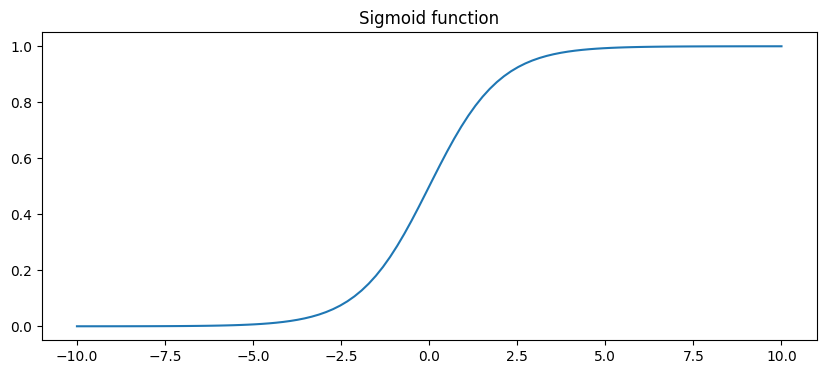

In [6]:
import matplotlib.pyplot as plt

z = np.linspace(-10,10,100)
sigmoid= 1 / (1 + np.exp(-z))

plt.figure(figsize=(10,4))
plt.plot(z,sigmoid)
plt.title("Sigmoid function")

<h2><strong>Architecture of Neural Networks</strong></h2>

ANN consists of three layers:

- Input layer: Receives the raw data. No math happens here
- Hidden layer: These layers extract features. "Deep" learning simply mean having many hidden layers
- output layer: Provides the final predictions.

<h2><strong>Forward propagation</strong></h2>

Forward propagation is the process of moving input data through the network to get an output

<strong>Step-by-Step:</strong>

1. Input is multiplied by weights and added to bias for the first hidden layer
2. An activation function is applied to these sums.
3. The results become the inputs for the next layer.
4. Repeat until you reach the output layer.

<h2><strong>Loss function</strong></h2>

The loss function measures how "wrong" the model is. Our goal is to minimize the value.


|Problem type| Loss function|
|------|--------|
|Regression|Mean squared Error(MSE)|
|Binary classification|Binary cross-entropy(log loss)|
|Multiclass classfication | Categorical cross-entropy|

<h2><strong>Backward Propagation</strong></h2>

Back propagation is how the neural network "learns". it is essentially the chain rule from calculus.

1. Calculate Error: How far is the prediction from the actual value.
2. Calculate Gradients: Find out how much each weight contributed to the error.
3. Update weights: Change the weights in the opposite direction of the gradient to reduce error.

In [8]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 3.5 MB/s  0:01:01m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 2.9 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 3.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 3.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.9 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import tensorflow as tf

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(units=6,activation='relu',input_dim=11))

model.add(Dense(units=6,activation='relu'))

model.add(Dense(units=1,activation='sigmoid'))


model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.summary()

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
X= np.array([
    [25,50000,1,600,0,1,0,20000,2,1,0],
    [40,70000,0,750,1,0,1,50000,5,0,1]
])

y = np.array([0,1])

In [17]:
model.fit(X,y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5000 - loss: 3859.4885
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 3775.3704
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 3691.5669
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 3608.0798
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 3524.9170
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 3442.0808
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 3359.5774
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 3277.4077
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 3195.5789
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 3114.0930
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 3032.9541
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10

In [18]:
prediction = model.predict(np.array([[30,60000,1,650,0,1,0,25000,2,1,0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [19]:
prediction

array([[0.]], dtype=float32)